In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv(r"C:\Users\ADITHYA A M\Downloads\netflix_catalogue.csv")
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())

Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


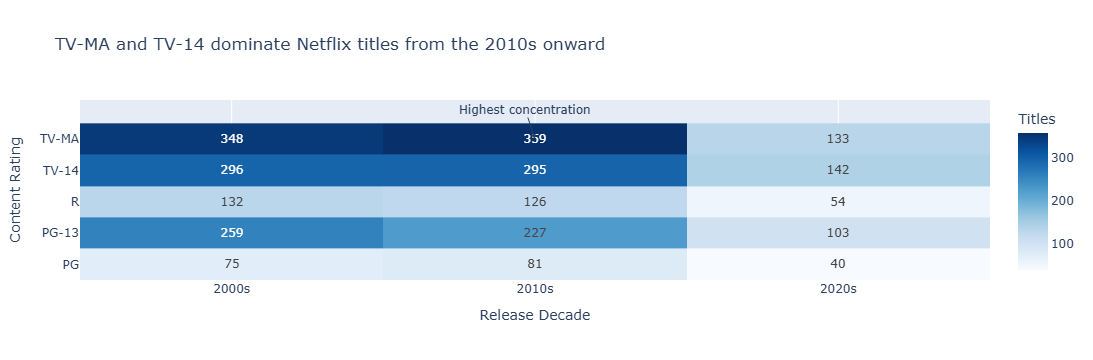

In [3]:
# Task 1 — Heatmap
# Content by Rating & Decade

# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Keep only the most common ratings
ratings_filter = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

heatmap_df = df[df['rating'].isin(ratings_filter)]

# Count titles by rating and decade
heatmap_data = (
    heatmap_df
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

# Create heatmap
fig = px.density_heatmap(
    heatmap_data,
    x='decade',
    y='rating',
    z='count',
    text_auto=True,
    color_continuous_scale='Blues',
    title='TV-MA and TV-14 dominate Netflix titles from the 2010s onward'
)

# Improve layout
fig.update_layout(
    xaxis_title='Release Decade',
    yaxis_title='Content Rating',
    coloraxis_colorbar_title='Titles'
)

# Annotate one important cell
fig.add_annotation(
    x='2010s',
    y='TV-MA',
    text='Highest concentration',
    showarrow=True,
    arrowhead=2
)

fig.show()

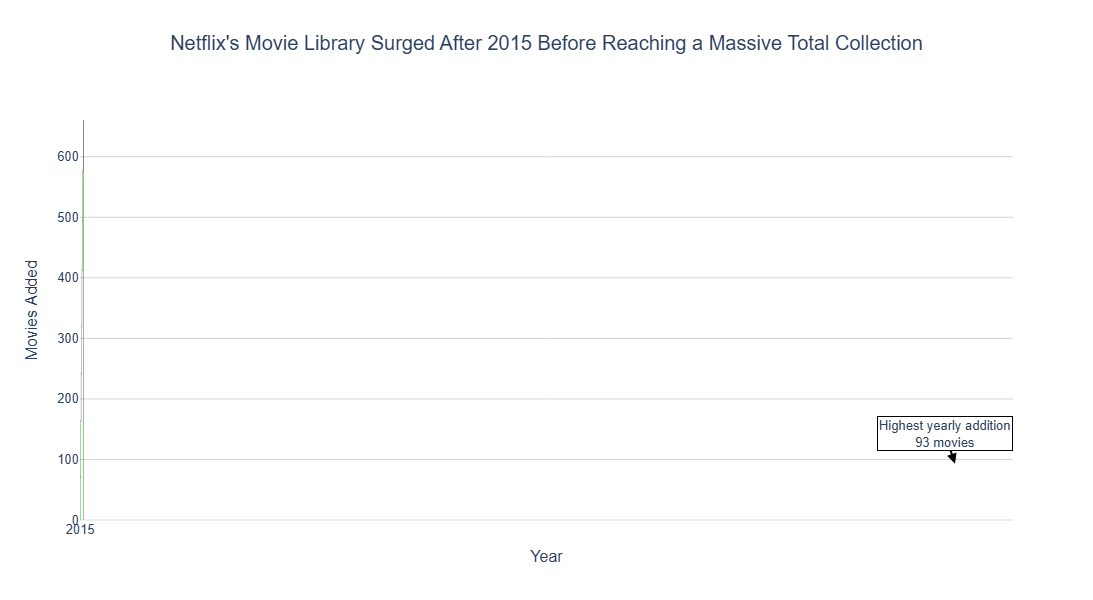

In [5]:
# =========================
# Task 2 — Styled Waterfall Chart
# Movie vs TV Show Additions
# =========================

# Filter Movies only
movies_df = df[df['type'] == 'Movie']

# Group by added year
movie_growth = (
    movies_df
    .groupby('added_year')
    .size()
    .reset_index(name='count')
)

# Filter years 2015–2022
movie_growth = movie_growth[
    (movie_growth['added_year'] >= 2015) &
    (movie_growth['added_year'] <= 2022)
]

# Find largest yearly addition
max_row = movie_growth.loc[movie_growth['count'].idxmax()]
max_year = str(max_row['added_year'])
max_value = max_row['count']

# Create waterfall chart
fig = go.Figure(go.Waterfall(
    name="Movie Growth",

    orientation="v",

    measure=["relative"] * len(movie_growth) + ["total"],

    x=[str(year) for year in movie_growth['added_year']] + ["Total"],

    y=list(movie_growth['count']) + [0],

    text=[f"+{v}" for v in movie_growth['count']] + [f"{movie_growth['count'].sum()}"],

    textposition="outside",

    connector={"line": {"color": "gray", "width": 1.5}},

    increasing={"marker": {"color": "green"}},

    decreasing={"marker": {"color": "red"}},

    totals={"marker": {"color": "blue"}}
))

# Add annotation on biggest growth year
fig.add_annotation(
    x=max_year,
    y=max_value,
    text=f"Highest yearly addition<br>{max_value} movies",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor="black",
    bgcolor="white",
    bordercolor="black",
    borderwidth=1
)

# Layout styling
fig.update_layout(
    title={
        'text': "Netflix's Movie Library Surged After 2015 Before Reaching a Massive Total Collection",
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=20)
    },

    xaxis_title="Year",
    yaxis_title="Movies Added",

    template="plotly_white",

    font=dict(
        family="Arial",
        size=13
    ),

    width=1000,
    height=600,

    showlegend=False
)

# Grid styling
fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='lightgray'
)

fig.show()
